# Clinical Trials EDA
Exploratory analysis of cleaned studies from `clinical_trials.db`.

In [84]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from query import load_all

df = load_all()
print(f"{len(df):,} studies loaded")
df.head(3)

2,173 studies loaded


,nct_id,title,status,phase1,phase2,phase3,phase4,phase_text,study_type,start_date,...,interventions,arm_groups,enrollment,enrollment_type,masking,allocation,intervention_model,primary_purpose,locations,ingested_at
0,NCT02434081,NIvolumab COmbination With Standard First-line...,COMPLETED,0,1,0,0,PHASE2,INTERVENTIONAL,2015-11-25,...,"[{""type"": ""DRUG"", ""name"": ""Nivolumab"", ""descri...","[{""label"": ""Chemo-radiotherapy with concurrent...",94.0,ACTUAL,NONE,NA,SINGLE_GROUP,TREATMENT,"[{""facility"": ""University Hospital Leuven"", ""c...",2026-05-08T20:07:01.263458+00:00
1,NCT00312975,"Randomized Study Of CP-675,206 or Best Support...",COMPLETED,0,1,0,0,PHASE2,INTERVENTIONAL,2006-05,...,"[{""type"": ""DRUG"", ""name"": ""CP-675,206"", ""descr...","[{""label"": ""Arm A"", ""type"": ""EXPERIMENTAL"", ""i...",90.0,ACTUAL,NONE,RANDOMIZED,PARALLEL,TREATMENT,"[{""facility"": ""Research Site"", ""city"": ""Benton...",2026-05-08T20:07:01.263624+00:00
2,NCT04687241,Almonertinib Versus Placebo as Adjuvant Therap...,ACTIVE_NOT_RECRUITING,0,0,1,0,PHASE3,INTERVENTIONAL,2021-04-30,...,"[{""type"": ""DRUG"", ""name"": ""Almonertinib"", ""des...","[{""label"": ""Almonertinib"", ""type"": ""EXPERIMENT...",192.0,ESTIMATED,TRIPLE,RANDOMIZED,PARALLEL,TREATMENT,"[{""facility"": ""Jilin Province Cancer Hospital""...",2026-05-08T20:07:01.263653+00:00


## Status breakdown

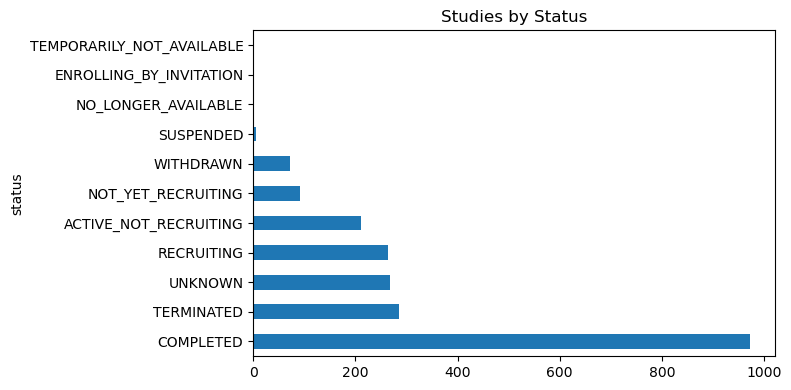

In [10]:
df['status'].value_counts().plot(kind='barh', figsize=(8, 4), title='Studies by Status')
plt.tight_layout()
plt.show()

## Phase distribution

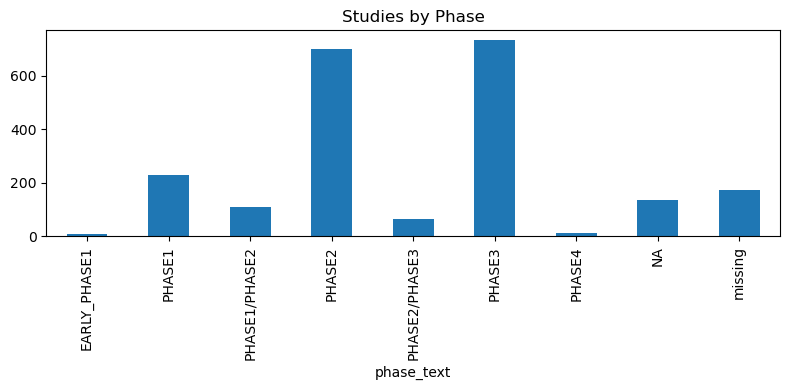

In [7]:
phase_order = ['EARLY_PHASE1', 'PHASE1', 'PHASE1/PHASE2', 'PHASE2', 'PHASE2/PHASE3', 'PHASE3', 'PHASE4', 'NA', 'missing']
assert set(df['phase_text'].dropna().unique()).issubset(set(phase_order)), "Unexpected phase values found"
assert set(phase_order).issubset(set(df['phase_text'].fillna('missing').unique())), "Phase order contains values not found in data"

counts = df['phase_text'].fillna('missing').value_counts()
counts = counts.reindex([p for p in phase_order if p in counts.index])

counts.plot(kind='bar', figsize=(8, 4), title='Studies by Phase')
plt.tight_layout()
plt.show()

## Enrollment histogram

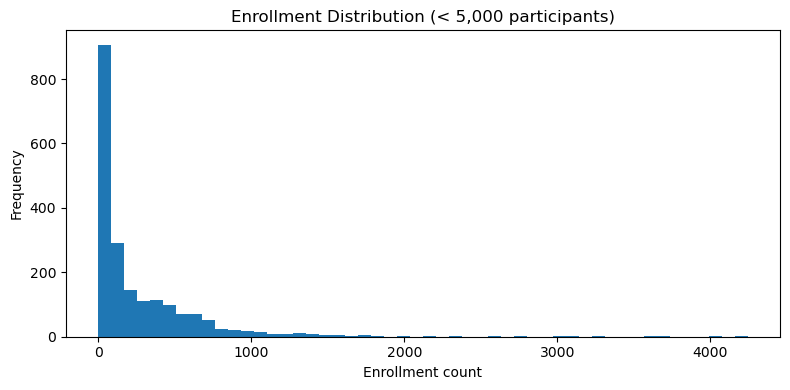

count     2079.000000
mean       270.676287
std        556.952626
min          0.000000
25%         32.000000
50%        100.000000
75%        363.500000
max      12400.000000
Name: enrollment, dtype: float64
Number of studies with 0 enrollment: 72


In [ ]:
enrollment = df['enrollment'].dropna()
enrollment[(enrollment < 5000)].plot(
    kind='hist', bins=50, figsize=(8, 4),
    title='Enrollment Distribution (< 5,000 participants)'
)
plt.xlabel('Enrollment count')
plt.tight_layout()
plt.show()
print(enrollment.describe())
print(f"Number of studies with 0 enrollment: {(enrollment == 0).sum()}")

## Trials opened per year

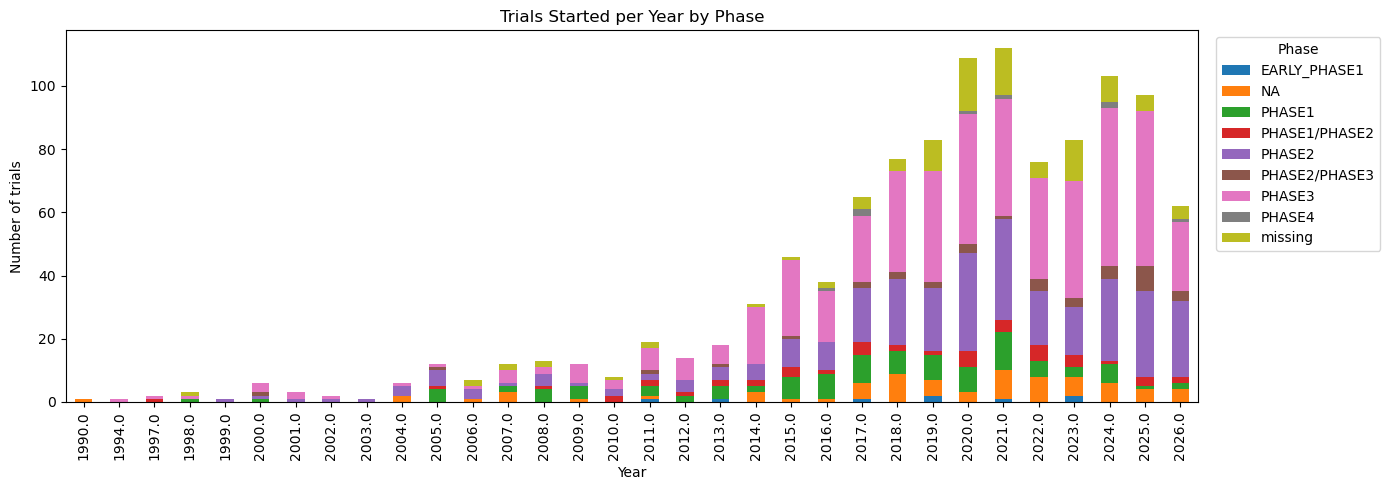

In [85]:
df['start_year'] = pd.to_datetime(df['start_date'], errors='coerce').dt.year

by_year_phase = (
    df[df['start_year'] >= 1990]
    .groupby(['start_year', df['phase_text'].fillna('missing')])
    .size()
    .unstack(fill_value=0)
)

by_year_phase.plot(kind='bar', stacked=True, figsize=(14, 5), title='Trials Started per Year by Phase')
plt.xlabel('Year')
plt.ylabel('Number of trials')
plt.legend(title='Phase', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Geographic breakdown — trials by country

87 unique countries


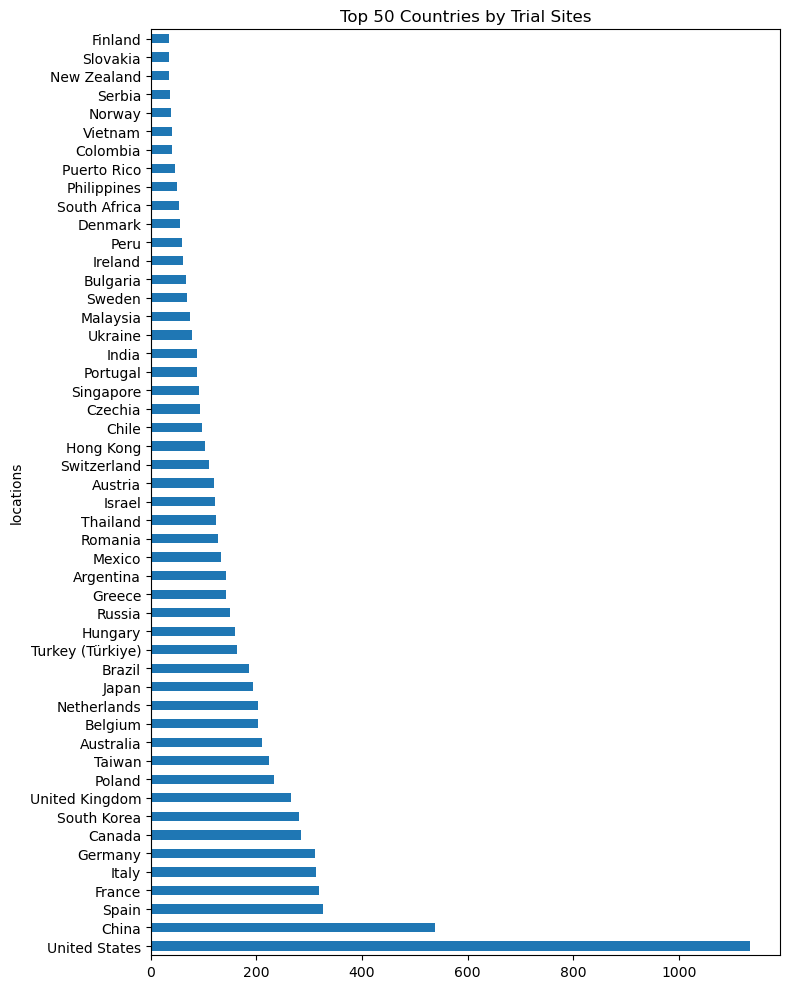

In [ ]:
# Each study can have many locations — explode them out
locs = df['locations'].dropna().apply(json.loads)
study_countries = locs.apply(lambda loc_set: {loc.get('country') for loc in loc_set}) # set of countries per study, so a country can only be counted once per study
countries = set(study_countries.explode().dropna()) # nan come from missing locations, many are widthdrawn studies with no locations
print(len(countries), "unique countries")
study_countries.explode().value_counts().head(50).plot(
    kind='barh', figsize=(8, 10), title='Top 50 Countries by Trial Sites'
)
plt.tight_layout()
plt.show()

## Geographic breakdown — US trials by state

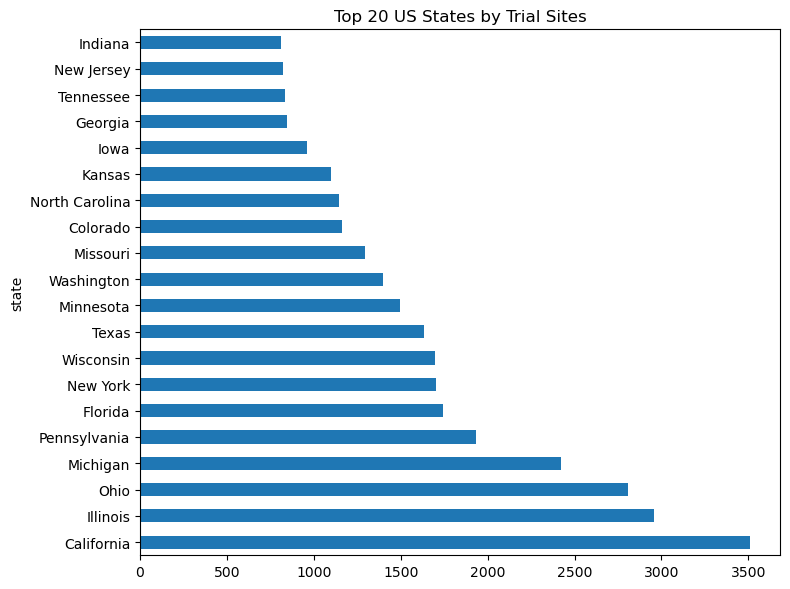

In [15]:
locs_df = pd.json_normalize(locs)
us = locs_df[locs_df['country'] == 'United States'].dropna(subset=['state'])
us['state'].value_counts().head(20).plot(
    kind='barh', figsize=(8, 6), title='Top 20 US States by Trial Sites'
)
plt.tight_layout()
plt.show()

## Sponsor class breakdown

{'Centre Hospitalier Intercommunal de Toulon La Seyne sur Mer', 'Tel-Aviv Sourasky Medical Center', 'CASI Pharmaceuticals, Inc.', 'Cancer Trials Ireland', 'Masonic Cancer Center, University of Minnesota', 'BerGenBio ASA', 'mAbxience Research S.L.', 'Clovis Oncology, Inc.', 'Addario Lung Cancer Medical Institute', 'National Institute of Cancerología', "Queen's University, Belfast", 'Suzhou Suncadia Biopharmaceuticals Co., Ltd.', 'Brown University', 'Istituto Scientifico H. San Raffaele', 'Imugene Limited', 'Barbara Ann Karmanos Cancer Institute', 'Genta Incorporated', 'Hansoh BioMedical R&D Company', 'Imperial College London', 'University of Manitoba', 'Bioven Sdn. Bhd.', 'Checkpoint Therapeutics, Inc.', 'Shanghai Huaota Biopharmaceutical Co., Ltd.', 'Oslo University Hospital', 'Dizal Pharmaceuticals', 'Second Affiliated Hospital of Nanchang University', 'National Hospital Organization Kinki-chuo Chest Medical Center', 'RemeGen Co., Ltd.', 'Spectrum Pharmaceuticals, Inc', 'Hellenic Onco

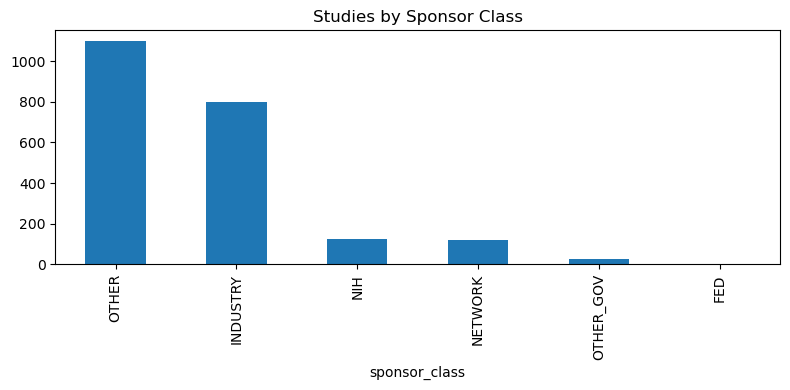

In [18]:
df['sponsor_class'].value_counts().plot(
    kind='bar', figsize=(8, 4), title='Studies by Sponsor Class'
)
print(set(df['sponsor']))
print("Number of unique sponsors: %s" % len(set(df['sponsor'])))
plt.tight_layout()
plt.show()